# Notebook 8: Mixed-effects models

*Quantitative Methods in Neuroscience, Master in Neuroscience, University of Geneva (2026-27)*

This is the practical companion to **Lecture 8, Mixed-effects Models and Random Effects**.

Mixed-effect models are powerful statistical models that can account for recurring issues in most experimental designs.
These issues are clear in the In the IBL dataset which you are now familiar with:

- **The observations from a single mouse are not independent of each other.** Rather, some mice may systematically perform better or faster than others.
- **The observations from a single session are not independent of each other.** One mouse may occasionally perform better/worse than usual.
- **The observations from a single research center are not independent of each other.** There may be conditions we are not aware of that affect how mice from one group perform.
- **The quantity of observations can be uneven/asymmetrical.** One mouse may have very few trials and another very many, which can violate assumptions of homogeneity.

Linear Mixed-effect models can account for most of these issues.

**WARNING**: Python is relatively limited for the implementation of of LMM, so we will stick to relatively simple models.
For more complex modeling, you should probably turn to R (e.g. packages lme4, lmerTest).
A useful notbook for LMMs in R: https://people.linguistics.mcgill.ca/~morgan/qmld-book/lmem.html




### By the end of this notebook you will be able to:
1. Understand **Multi-level data structures** and how to deal with nested designs
2. Extract the hierarchical information relevant to build linear mixed-efefct models
3. Visualize variations across hierarchical levels using **Spaghetti plots**
4. Fit **linear mixed-effect models** of various complexity
5. Understand **random effects**: random intercepts and random slopes
5. See the technical and statistical differences between LMMs and ANOVAs and linear regressions

### Table of contents
0. [Loading the nested data structure](#part-0-loading-the-nested-data-structure)
1. [Exploring and understanding the nested structure](#part-1-exploring-and-understanding-the-nested-structure)
2. [Spaghetti plots - visualizing individual variation](#part-2-spaghetti-plots---visualizing-individual-variation)
3. [Not yet linear mixed-effect models](#part-3-not-yet-linear-mixed-effect-models)
4. [Linear mixed models](#part-4-linear-mixed-models)
5. [Multi-level data by session (optional)](#part-5-optional-multi-level-data-by-session)
6. [Key takeaways & best practices](#part-6-key-takeaways--best-practices)
7. [References & further reading](#part-7-references--further-reading)




> **How to read this notebook.** Markdown cells explain the concept, code cells implement it.
> **`▶ Task`** boxes are short exercises, tagged by difficulty:
>
> - **⭐** essential: run it, understand it, change it slightly.
> - **⭐⭐** intermediate: complete the missing lines or write a short function.
> - **⭐⭐⭐** optional challenge: build a fuller analysis yourself.
>
> If you use AI help, treat it as a tutor and not a substitute: you should be able to read every
> line and say what it does.






## Overview

This tutorial introduces **mixed-effects models** (also called random-effects or hierarchical models) using real neuroscience data from the **International Brain Laboratory (IBL)**. We'll work through:

1. **Multi-level data structures**: Understanding nested designs
2. **Subject/session identifiers**: How to specify the hierarchical levels
3. **Extracting model parameters**: Fixed effects, random effects, and predictions
4. **Spaghetti plots**: Visualizing individual variation

### Why mixed-effects models?

In neuroscience and behavioral research, data is **hierarchical**:
- Trials are nested within **sessions**
- Sessions are nested within **subjects** (or animals)
- Subjects are nested within **labs** (sometimes)

Standard regression assumes all observations are independent, but nested data violates this assumption. **Mixed-effects models** account for this structure by including:
- **Fixed effects**: parameters we care about (e.g., effect of stimulus contrast)
- **Random effects**: account for individual variation around the fixed effects

### The IBL dataset

This notebook uses the **IBL visual decision-making task** dataset:
- **10 mice** performing a decision task
- **~100,000 trials** total
- **160 sessions** (8 sessions per mouse, 2 phases)
- Nested structure: **trials → sessions → subjects**




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# For mixed-effects models, we'll use statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Part 0: Loading the Nested Data Structure


Let's start by loading our dataset (you can just run this chunk):

In [2]:
# --- Load the data: the trial table + its companion subject-metadata table
df       = pd.read_csv("../notebooks/data/ibl_2afc.csv.gz")
subjects = pd.read_csv("../notebooks/data/ibl_2afc_subjects.csv")

# the three cohorts used throughout: two wild-type labs + the ASD line
subjects["cohort"] = np.where(subjects["lab"] == "churchlandlab", "CSHL-WT",
                      np.where(subjects["group"] == "WT", "NYU-WT", "CSP-ASD"))

# bring the subject-level factors (group / genotype / lab / cohort) onto every trial
df = df.merge(subjects[["subject_id", "group", "genotype", "lab", "cohort"]],
              on="subject_id")

print("trials   :", df.shape)
print("subjects :", subjects.shape)
print("phases   :", sorted(df["phase"].unique()))
print("cohorts  :", subjects["cohort"].value_counts().to_dict())

# Per-mouse colours, one colour family per cohort:
#   Churchland WT = blues, Angelaki WT = oranges, Angelaki ASD = reds.
MOUSE_COLOR = {}
for coh, cmap_name in [("CSHL-WT", "Blues"), ("NYU-WT", "Oranges"), ("CSP-ASD", "Reds")]:
    coh_mice = sorted(subjects.loc[subjects["cohort"] == coh, "subject_id"])
    shades = plt.get_cmap(cmap_name)(np.linspace(0.45, 0.92, len(coh_mice)))
    MOUSE_COLOR.update(zip(coh_mice, shades))

# Solid cohort colours for the group comparisons (§9), same families.
COHORT_COLOR = {"CSHL-WT": "#1f77b4", "NYU-WT": "#ff7f0e", "CSP-ASD": "#d62728"}

df.tail(10)

trials   : (694182, 23)
subjects : (30, 10)
phases   : ['trained', 'training']
cohorts  : {'CSHL-WT': 10, 'CSP-ASD': 10, 'NYU-WT': 10}


,trial_id,subject_id,phase,session,trial_in_session,signed_contrast,stimulus_side,response,correct,no_go,...,reward_volume,stim_on_time_s,go_cue_time_s,first_movement_time_s,choice_time_s,feedback_time_s,group,genotype,lab,cohort
694172,694172,CSP013,trained,8,649,0.2500,right,1.0,1.0,False,...,1.5,3717.2712,3717.2721,3719.0548,3719.2642,3719.2643,ASD,Cntnap2 (ASD model),angelakilab,CSP-ASD
694173,694173,CSP013,trained,8,650,0.1250,right,1.0,1.0,False,...,1.5,3722.5810,3722.5820,3726.2368,3726.4971,3726.4972,ASD,Cntnap2 (ASD model),angelakilab,CSP-ASD
694174,694174,CSP013,trained,8,651,0.1250,right,1.0,1.0,False,...,1.5,3729.5711,3729.5723,3741.7758,3742.0404,3742.0405,ASD,Cntnap2 (ASD model),angelakilab,CSP-ASD
694175,694175,CSP013,trained,8,652,1.0000,right,1.0,1.0,False,...,1.5,3745.6036,3745.6044,3745.9528,3746.2601,3746.2602,ASD,Cntnap2 (ASD model),angelakilab,CSP-ASD
694176,694176,CSP013,trained,8,653,0.0000,zero,0.0,1.0,False,...,1.5,3749.5034,3749.5044,3749.7108,3749.8589,3749.8590,ASD,Cntnap2 (ASD model),angelakilab,CSP-ASD
694177,694177,CSP013,trained,8,654,1.0000,right,1.0,1.0,False,...,1.5,3754.6306,3754.6317,3761.4028,3761.7888,3761.7889,ASD,Cntnap2 (ASD model),angelakilab,CSP-ASD
694178,694178,CSP013,trained,8,655,0.2500,right,1.0,1.0,False,...,1.5,3765.0971,3765.0979,3772.5398,3772.6800,3772.6801,ASD,Cntnap2 (ASD model),angelakilab,CSP-ASD
694179,694179,CSP013,trained,8,656,1.0000,right,1.0,1.0,False,...,1.5,3776.4802,3776.4811,3782.1208,3782.3550,3782.3551,ASD,Cntnap2 (ASD model),angelakilab,CSP-ASD
694180,694180,CSP013,trained,8,657,0.0625,right,0.0,0.0,False,...,0.0,3790.1967,3790.1976,3796.1108,3796.2277,3796.2289,ASD,Cntnap2 (ASD model),angelakilab,CSP-ASD
694181,694181,CSP013,trained,8,658,0.2500,right,1.0,1.0,False,...,1.5,3800.4696,3800.4705,3835.6968,3837.9098,3837.9099,ASD,Cntnap2 (ASD model),angelakilab,CSP-ASD


> **▶ Task 0.1 ⭐⭐ - Subset the data.**
> For this session, we will only focus on the `trained` data.
> In the following chunk:
> - Subset the dataset to trials from `trained` phase.
> - Focus on valid trials (when `no-go` has value `False`)
> - Remove rows with NaN in `signed_contrast` 

In [3]:
# TODO 0.1, fill in the blanks marked ____, uncomment, and run.

# subset to trained data only
# df_trained = _____


# Focus on trials with valid responses
# df_trained_clean = _____

# Remove rows with NaN in key variables
# df_trained_clean = _____


# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
df_trained = df.query("phase == 'trained'").copy()

# Focus on trials with valid responses
df_trained_clean = df_trained[df_trained['no_go'] == False]

# Remove rows with NaN in key variables
df_trained_clean = df_trained_clean.dropna(subset=['signed_contrast'])



Let's see what our manipulation did:

In [4]:
df_trained_clean.head(10)

print(f"Original dataset: {len(df)} trials")
print(f"After subsetting to trained trials: {len(df_trained)} trials")
print(f"After removing NaNs and incorrect trials: {len(df_trained_clean)} trials")
print(f"Removed {len(df_trained) - len(df_trained_clean)} incorrect trials\n")

Original dataset: 694182 trials
After subsetting to trained trials: 185487 trials
After removing NaNs and incorrect trials: 184581 trials
Removed 906 incorrect trials



# Part 2: Exploring and Understanding the Nested Structure

The IBL dataset has a **three-level hierarchical structure**:

```
Level 0: LABS (3 research laboratories)
├── Level 1: SUBJECTS (30 mice)
│   ├── Level 2: SESSIONS (8 trained sessions per mouse)
│   │   └── Level 3: TRIALS (~625 trials per session)
```

Key columns for the hierarchy:
- `subject_id`: unique identifier for each mouse (e.g., 'CSHL051')
- `session`: session number within a subject (1–8)
- `trial_id`: unique row index (trial identifier)

In [5]:
# Explore the hierarchical structure
print("=== HIERARCHICAL STRUCTURE ===\n")

n_subjects = df_trained_clean['subject_id'].nunique()
n_sessions = df_trained_clean['session'].nunique()
n_trials = len(df_trained_clean)

print(f"Number of unique subjects: {n_subjects}")
print(f"Number of unique sessions (total): {n_sessions}")
print(f"Total number of trials: {n_trials}\n")

# Check trials per session per subject
trials_per_subject = df_trained_clean.groupby('subject_id').size()
print(f"Trials per subject (summary):")
print(f"  Min: {trials_per_subject.min()}")
print(f"  Max: {trials_per_subject.max()}")
print(f"  Mean: {trials_per_subject.mean():.1f}\n")


# Display one subject's hierarchy
sample_subject = df_trained_clean[df_trained_clean['subject_id'] == 'NYU-32']
print(f"EXAMPLE: Subject (NYU-32) has {len(sample_subject)} trials")


=== HIERARCHICAL STRUCTURE ===

Number of unique subjects: 30
Number of unique sessions (total): 8
Total number of trials: 184581

Trials per subject (summary):
  Min: 3191
  Max: 9047
  Mean: 6152.7

EXAMPLE: Subject (NYU-32) has 5773 trials


For mixed-effects modeling, we need **explicit identifiers** for each level of the hierarchy. We already have subject identifiers and sessions identifiers, but the session identifiers have the same names across subjects. Let's create unique session identifiers.

In [6]:
# Create unique session identifiers (for more complex models)
# combining subject_id and session number
df_trained_clean['session_id'] = df_trained_clean['subject_id'] + '_s' + df_trained_clean['session'].astype(str)

print("New columns created:")
print(f"  - abs_contrast: absolute value of signed_contrast")
print(f"  - session_id: unique identifier for each session\n")

New columns created:
  - abs_contrast: absolute value of signed_contrast
  - session_id: unique identifier for each session



### Visualizing the Hierarchical Structure

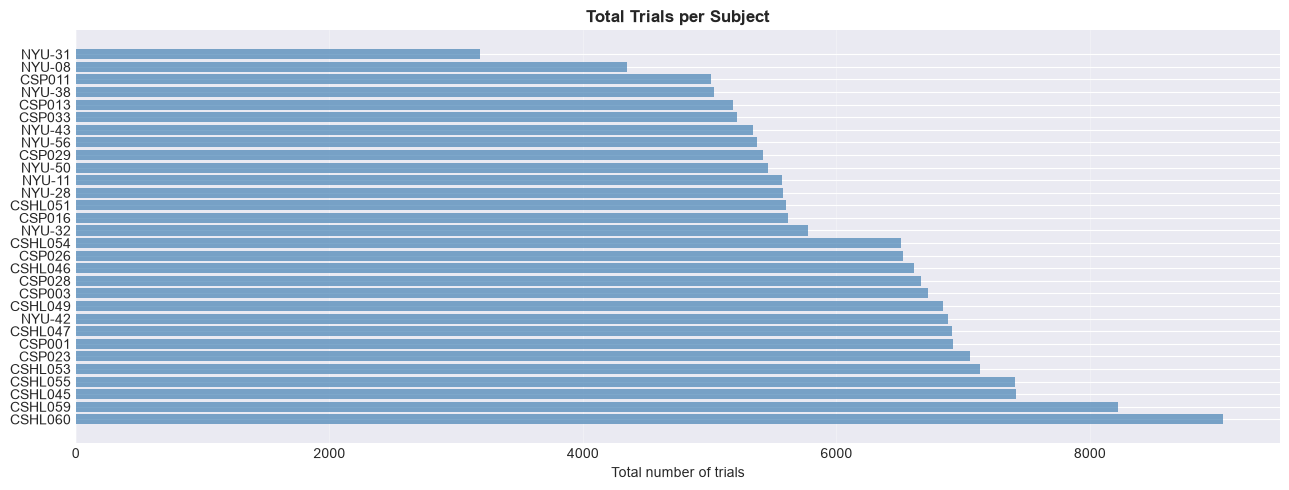

In [7]:
# Visualize trials per subject

fig, ax = plt.subplots(figsize=(13, 5))

# Plot: Total trials per subject
trials_per_subject = df_trained_clean.groupby('subject_id').size().sort_values(ascending=False)
ax.barh(range(len(trials_per_subject)), trials_per_subject.values, color='steelblue', alpha=0.7)
ax.set_yticks(range(len(trials_per_subject)))
ax.set_yticklabels(trials_per_subject.index)
ax.set_xlabel('Total number of trials')
ax.set_title('Total Trials per Subject', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()



> **▶ Task 1.1 ⭐⭐ - Visualize unique sessions**
> Copy and modify the code chunk above to visualize the number of trials in each unique session

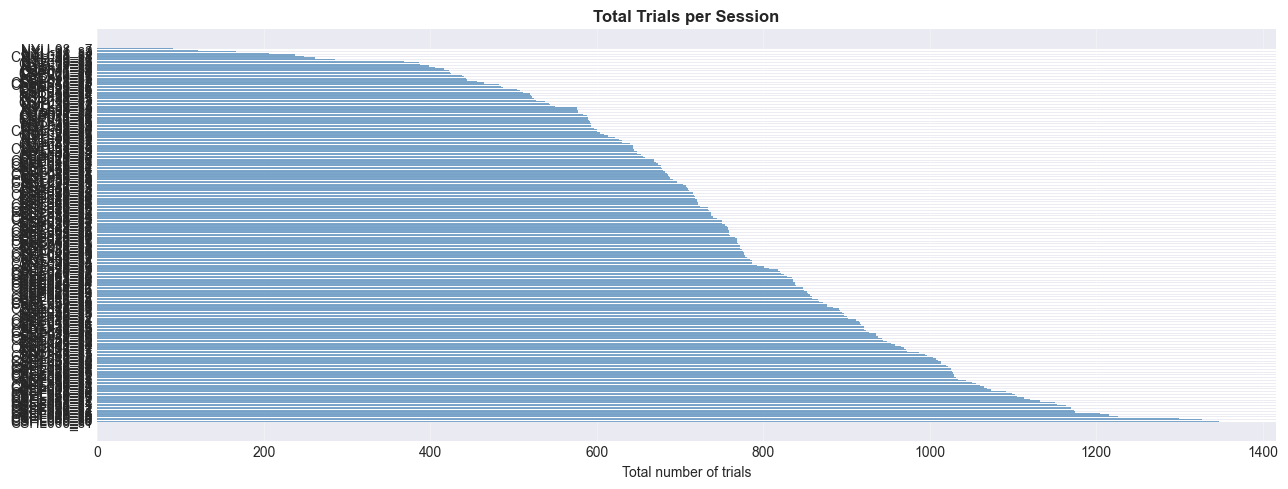

In [ ]:

# TODO 1.1, Copy and modify the code chunk above and run.



# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION

# Visualize trials per session

fig, ax = plt.subplots(figsize=(13, 5))

# Plot: Total trials per session
trials_per_session = df_trained_clean.groupby('session_id').size().sort_values(ascending=False)
ax.barh(range(len(trials_per_session)), trials_per_session.values, color='steelblue', alpha=0.7)
ax.set_yticks(range(len(trials_per_session)))
ax.set_yticklabels(trials_per_session.index)
ax.set_xlabel('Total number of trials')
ax.set_title('Total Trials per Session', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Part 2: Spaghetti Plots - Visualizing Individual Variation

In this notebook, we will mainly look at the RTs (reaction time) and how it changes based on the contrast values, and maybe the research lab / mouse phenotype.
First, we can visualize this using **spaghetti plots**.


A **spaghetti plot** shows individual trends overlaid on the group trend. Each "noodle" is one subject's curve. This is the key visualization for mixed-effects models!

Why are spaghetti plots important?
- Show **individual variation** around the population trend
- Make **random slopes** visible
- Reveal **outliers** or interesting subjects
- Motivate the need for mixed-effects models

In [8]:
# --- First clean up the dataset once more by creating an absolute contrast column, removing NaNs, and filtering out extreme contrasts

df_trained_clean["abs_contrast"] = df_trained_clean["signed_contrast"].abs()

df_trained_clean = df_trained_clean.dropna(subset=["reaction_time_s"])
df_trained_clean = df_trained_clean[df_trained_clean['abs_contrast'] < 1]

rt_subjects = (df_trained_clean.groupby(["subject_id", "abs_contrast", "cohort", "genotype"])["reaction_time_s"].mean().reset_index())
         


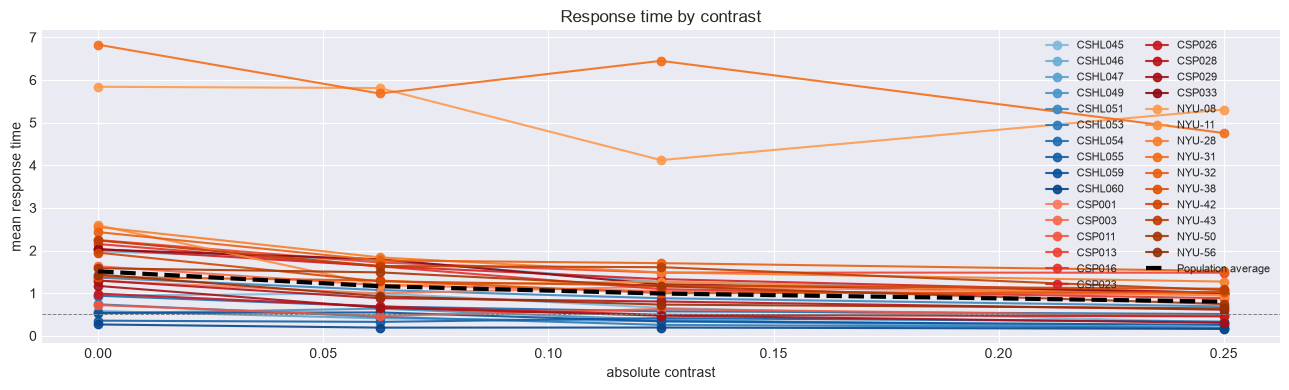

In [9]:
# Visualize subject-level RTs by contrast

fig, ax = plt.subplots(figsize=(13, 4), sharey=True)

# Spaghetti Plot for each subject
for subj, g in rt_subjects.groupby("subject_id"):
    ax.plot(g["abs_contrast"], g["reaction_time_s"], "o-", color=MOUSE_COLOR[subj],
            label=subj, alpha=0.9)
    
# Plot population average RT by contrast
population_summary = df_trained_clean.groupby('abs_contrast')['reaction_time_s'].mean().reset_index()
ax.plot(population_summary['abs_contrast'], population_summary['reaction_time_s'],
        color='black', linewidth=3, linestyle='--', label='Population average')
    
ax.axhline(0.5, color="gray", lw=0.7, ls="--")
ax.set_title(f"Response time by contrast"); ax.set_xlabel("absolute contrast"); ax.set_ylabel("mean response time")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

We can also visualize by-subject data, looking at what trials look like in a single subject:

> **▶ Task 2.1 ⭐ - Visualize by-subject RT trials**
> - Run the chunk below.
> - Modify the code to show data from different mice (e.g., CSP011, CSP033, NYU-56)
> - The code below currently shows only a subset of trials for each subject. Find the part that does this, and modify it to display 300 trials per subject.

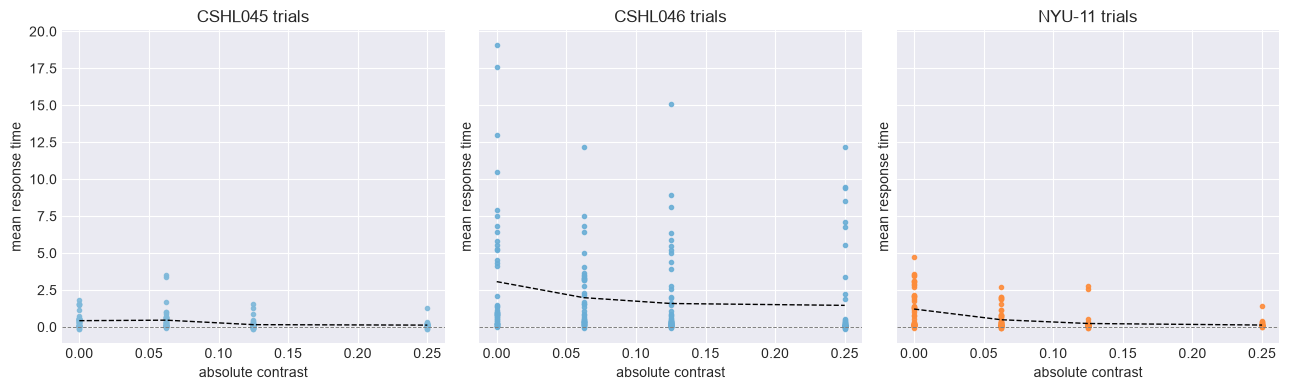

In [10]:
# TODO 2.1, Run this chunk, then modify it to visualize other mice and change the number of trials plotted per mouse. 
# You can also change the y-axis limits to zoom in on the RTs.


fig, axes = plt.subplots(1, 3,figsize=(13, 4), sharey=True)

for ax, subj in zip(axes, ["CSHL045", "CSHL046", "NYU-11"]):
    rt_sample_subject = df_trained_clean[df_trained_clean['subject_id'] == subj].head(200)
    for trial, g in rt_sample_subject.groupby("trial_id"):
        ax.plot(g["abs_contrast"], g["reaction_time_s"], "o-", color=MOUSE_COLOR[subj],
             alpha=0.9, markersize=3)        
        
    subj_summary = rt_sample_subject.groupby('abs_contrast')['reaction_time_s'].mean().reset_index()
    ax.plot(subj_summary['abs_contrast'], subj_summary['reaction_time_s'],
            color='black', linewidth=1, linestyle='--')
    
        
    ax.axhline(0, color="gray", lw=0.7, ls="--")
    ax.set_title(f"{subj} trials"); ax.set_xlabel("absolute contrast"); ax.set_ylabel("mean response time")
    ax.legend(fontsize=8, ncol=2)


plt.tight_layout(); plt.show()

### What can we see from these models?

- There seems to be an effect of contrast: the higher the contrast, the faster the reaction time
- No clear effect of group
- Lots of variability: a couple mice are very slow in general, some mice have very variable trials, and some mice have more pronounced contrast effects than others.

## Part 3: Not yet Linear Mixed-effect Models

Let's see how LMMs differ from other methods, and why it is useful.
We start by comparing two approaches for reaction time:

1. **Subject-wise ANOVA**: use subject-level averages to preserve independence across subjects
2. **Trial-wise linear regression**: use every trial and regress RT on contrast without looking at subjects.


Subject-wise, repeated measures ANOVA loses trial-level information. As seen above, certin subjects have less trials than others, which creates imbalance. If such a subject has an outlier behavior, it may drastically affect the results.

Linear regression can be fit on subject means (like RM ANOVA), or on all trials. However, fitting a linear regression on all trials assumes independence between trials, which is misleading. It does not account for inter-subject variability.


> **▶ Task 3.1 ⭐⭐ - Fit different models to the data**
> - Fit a Repeated Measures ANOVA on the `rt_subjects` dataset, with `reaction_time_s` as a dependent variable, `abs_contrast` as a within-subject factor, and `subject_id` as the grouping variable.
> - Fit a Linear Regression on the `rt_subjects` dataset, with `reaction_time_s` as a function of `abs_contrast`
> - Fit another Linear Regression, this time on all trials.

#### ANOVA

In [11]:
# TODO 3.1.1, fit a repeated measures ANOVA to the subject-level RTs and print the results.

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION

# repeated measures ANOVA: average RT for each subject and contrast
anova_rm = sm.stats.AnovaRM(rt_subjects, 'reaction_time_s', 'subject_id', within=['abs_contrast']).fit()
print("Repeated Measures ANOVA:")
print(anova_rm)


Repeated Measures ANOVA:
                  Anova
             F Value Num DF  Den DF Pr > F
------------------------------------------
abs_contrast 43.7824 3.0000 87.0000 0.0000



#### Linear Regression:

In [12]:
# TODO 3.1.2, fit a linear regression to the subject-level RTs and print the results.


# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION


# Simple regression on RT by subject
lm_rt = smf.ols('reaction_time_s ~ abs_contrast', data=rt_subjects).fit()
print('Simple OLS regression on RT:')
print(lm_rt.summary().tables[1])
print('\nSlope on abs_contrast:', round(lm_rt.params['abs_contrast'], 4))
print('=' * 80)

Simple OLS regression on RT:
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        1.6439      0.180      9.138      0.000       1.288       2.000
abs_contrast    -2.8088      1.256     -2.236      0.027      -5.296      -0.321

Slope on abs_contrast: -2.8088


In [13]:
# TODO 3.1.3, fit a linear regression to the trial-level RTs and print the results.


# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION


# Simple regression on RT by trials
lm_rt = smf.ols('reaction_time_s ~ abs_contrast', data=df_trained_clean).fit()
print('Simple OLS regression on RT:')
print(lm_rt.summary().tables[1])
print('\nSlope on abs_contrast:', round(lm_rt.params['abs_contrast'], 4))
print('=' * 80)

Simple OLS regression on RT:
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        1.4096      0.017     84.995      0.000       1.377       1.442
abs_contrast    -2.6754      0.116    -23.117      0.000      -2.902      -2.449

Slope on abs_contrast: -2.6754


What are the main differences between the two regression analyses performed on RT by subject and RT by trials?


# Part 4. Linear Mixed Models

### 4.1 Random Intercepts

Linear Mixed-effects models allows us to account for subject-wise variations while modelling the whole data.


**Random Intercepts** let each subject have its own baseline RT.
This way, the effect of interest (contrast) is independent from each subject's general speed in the task. 

**Formula**: `reaction_time_s ~ abs_contrast` with a random intercept for `subject_id`

**Interpretation**:
- **Fixed effect**: average effect of contrast on RT
- **Random effect**: Baseline RT for each subject


In [14]:

# Linear mixed model: random intercepts for subject
lmm_rt_ri = smf.mixedlm(
    'reaction_time_s ~ abs_contrast',
    data=df_trained_clean,
    groups=df_trained_clean['subject_id']
).fit(reml=False)
print('Linear mixed model with random intercepts:')
print(lmm_rt_ri.summary())
print('=' * 80)



Linear mixed model with random intercepts:
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: reaction_time_s
No. Observations: 136757  Method:             ML             
No. Groups:       30      Scale:              14.8740        
Min. group size:  732     Log-Likelihood:     -378736.6967   
Max. group size:  7218    Converged:          Yes            
Mean group size:  4558.6                                     
--------------------------------------------------------------
              Coef.   Std.Err.     z     P>|z|  [0.025  0.975]
--------------------------------------------------------------
Intercept      1.626     0.224    7.246  0.000   1.186   2.066
abs_contrast  -2.676     0.113  -23.703  0.000  -2.897  -2.455
Group Var      1.502     0.101                                



The first table gives summary info on the data that the model is fitted on (left), and on the construction of the model (right).
Note that the model converged, meaning that it found a fit appropriate to the data.

The second table is what interests us: it reads like a linear regression outpu, except we now have the `Group Var` row giving us information on how much subjects vary (the variance across random intercepts)

### 4.2 Random Slopes

We can go one step further by including a **Random Slope** in the model

**Random Slopes** account for individual relationships that each group (here, each subject) have with a predictor.
This way, the model remains strong even if subjects show very different effects of contrasts on RT.

**Formula**: `reaction_time_s ~ abs_contrast` with a random intercept for `subject_id` and a random slope for `~abs_contrast`

**Interpretation**:
- **Fixed effect**: Average effect of contrast on RT
- **Random effect**: Baseline RT for each subject
- **Random slope**: Individual effect of contrast on RT

In [15]:

# Linear mixed model: random intercepts and slopes for subject
lmm_rt_rs = smf.mixedlm(
    'reaction_time_s ~ abs_contrast',
    data=df_trained_clean,
    groups=df_trained_clean['subject_id'],
    re_formula='~abs_contrast'
).fit(reml=False)
print('Linear mixed model with random intercepts and slopes:')
print(lmm_rt_rs.summary())
print('=' * 80)



Linear mixed model with random intercepts and slopes:
               Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   reaction_time_s
No. Observations:   136757    Method:               ML             
No. Groups:         30        Scale:                14.8579        
Min. group size:    732       Log-Likelihood:       -378678.5381   
Max. group size:    7218      Converged:            Yes            
Mean group size:    4558.6                                         
-------------------------------------------------------------------
                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                 1.649    0.252  6.540 0.000  1.155  2.144
abs_contrast             -2.896    0.310 -9.339 0.000 -3.503 -2.288
Group Var                 1.899    0.130                           
Group x abs_contrast Cov -1.877    0.154                           
abs_contr

This time, the output table also has rows giving information about the variance of the abs_contrast effect across subjects.

notice how adding the random slopes increased the coef, but reduced the z value and widened the confidence intervals.
In this example, it does not change much as the data is relatively uniform - but in certaincases, it can remove or add significant effects!

> ### **▶ Task 4.1 ⭐⭐⭐ - create models with contrast AND cohort as predictors**
> #### Compare linear regression by subjects, by trials, and linear mixed model

> **How do the effects change from one model to another? Why?**

> *Things to think about:*
> - *How is the cohort implemented as a predictor?*
> - *Should you add a Participant-by-Cohort slope? Why?*

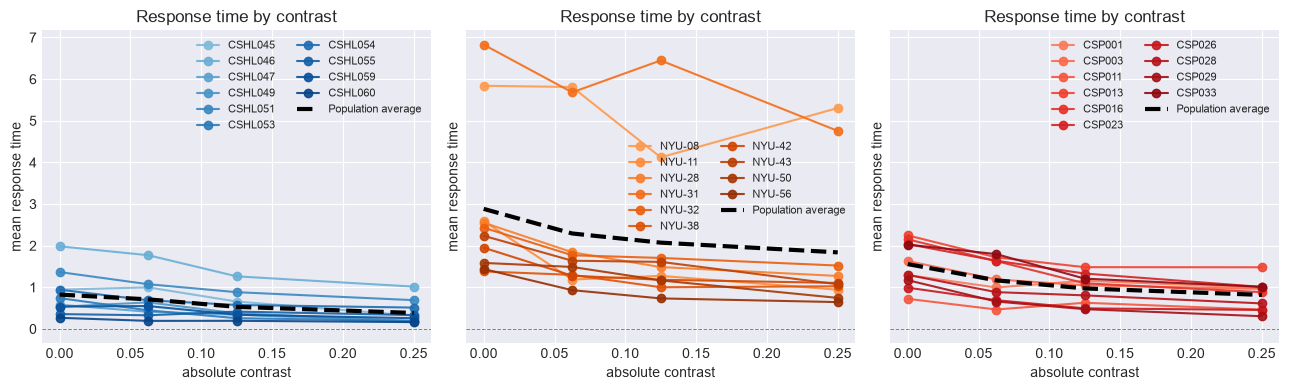

In [18]:
# Visualize RT by contrast for each cohort (NOT exercise)

fig, axes = plt.subplots(1, 3,figsize=(13, 4), sharey=True)

for ax, cohort in zip(axes, ["CSHL-WT", "NYU-WT", "CSP-ASD"]):
    rt_subject_cohort = rt_subjects[rt_subjects['cohort'] == cohort]
    for subj, g in rt_subject_cohort.groupby("subject_id"):
        ax.plot(g["abs_contrast"], g["reaction_time_s"], "o-", color=MOUSE_COLOR[subj],
                label=subj, alpha=0.9)        

    population_summary = rt_subject_cohort.groupby('abs_contrast')['reaction_time_s'].mean().reset_index()
    ax.plot(population_summary['abs_contrast'], population_summary['reaction_time_s'],
            color='black', linewidth=3, linestyle='--', label='Population average')
        
    ax.axhline(0, color="gray", lw=0.7, ls="--")
    ax.set_title(f"Response time by contrast"); ax.set_xlabel("absolute contrast"); ax.set_ylabel("mean response time")
    ax.legend(fontsize=8, ncol=2)

plt.tight_layout(); plt.show()

In [ ]:
# TODO 4.1.1. fit the linear regression by subjects and print the results.

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
lm_cohort_rt_bytrials = smf.ols('reaction_time_s ~ abs_contrast*C(cohort)', data=rt_subjects).fit()
print('Simple OLS regression on RT:')
print(lm_cohort_rt_bytrials.summary().tables[1])
print('\nSlope on abs_contrast:', round(lm_cohort_rt_bytrials.params['abs_contrast'], 4))
print('=' * 80)

Simple OLS regression on RT:
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             0.8073      0.264      3.057      0.003       0.284       1.330
C(cohort)[T.CSP-ASD]                  0.6239      0.373      1.671      0.098      -0.116       1.364
C(cohort)[T.NYU-WT]                   1.8859      0.373      5.050      0.000       1.146       2.626
abs_contrast                         -1.7917      1.844     -0.972      0.333      -5.445       1.861
abs_contrast:C(cohort)[T.CSP-ASD]    -0.9844      2.608     -0.377      0.707      -6.150       4.181
abs_contrast:C(cohort)[T.NYU-WT]     -2.0669      2.608     -0.793      0.430      -7.233       3.099

Slope on abs_contrast: -1.7917


In [20]:
# TODO 4.1.2. fit the linear regression by trials  and print the results.

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
lm_cohort_rt_bytrials = smf.ols('reaction_time_s ~ abs_contrast*C(cohort)', data=df_trained_clean).fit()
print('Simple OLS regression on RT:')
print(lm_cohort_rt_bytrials.summary().tables[1])
print('\nSlope on abs_contrast:', round(lm_cohort_rt_bytrials .params['abs_contrast'], 4))
print('=' * 80)

Simple OLS regression on RT:
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             0.7859      0.027     29.446      0.000       0.734       0.838
C(cohort)[T.CSP-ASD]                  0.6491      0.039     16.660      0.000       0.573       0.726
C(cohort)[T.NYU-WT]                   1.4278      0.041     34.972      0.000       1.348       1.508
abs_contrast                         -1.7272      0.186     -9.277      0.000      -2.092      -1.362
abs_contrast:C(cohort)[T.CSP-ASD]    -1.0880      0.272     -4.000      0.000      -1.621      -0.555
abs_contrast:C(cohort)[T.NYU-WT]     -2.0640      0.285     -7.247      0.000      -2.622      -1.506

Slope on abs_contrast: -1.7272


In [19]:
# TODO 4.1.3. fit the linear mixed-effect model and print the results.


# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION

lmm_rt_ri = smf.mixedlm(
    'reaction_time_s ~ abs_contrast*C(cohort)',
    data=df_trained_clean,
    groups=df_trained_clean['subject_id'],
    re_formula='~abs_contrast'
).fit(reml=False)
print('Linear mixed model with random intercepts:')
print(lmm_rt_ri.summary())
print('=' * 80)

Linear mixed model with random intercepts:
                   Mixed Linear Model Regression Results
Model:                 MixedLM      Dependent Variable:      reaction_time_s
No. Observations:      136757       Method:                  ML             
No. Groups:            30           Scale:                   14.8579        
Min. group size:       732          Log-Likelihood:          -378671.5277   
Max. group size:       7218         Converged:               Yes            
Mean group size:       4558.6                                               
----------------------------------------------------------------------------
                                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------
Intercept                          0.805    0.354  2.273 0.023  0.111  1.500
C(cohort)[T.CSP-ASD]               0.627    0.501  1.251 0.211 -0.355  1.609
C(cohort)[T.NYU-WT]                1.905    0.501  3.

## Part 5 (optional): Multi-Level Data by Session

In the IBL dataset, we have **sessions** nested within subjects. This creates a **three-level hierarchy**:
- Level 3: Trials
- Level 2: Sessions (within subjects)
- Level 1: Subjects

In R, it is easy to implement complex nested structures. In Python, less so. But we have created unique `session_id` identifiers that can act as a proxy for model nesting session within subjects.

> **▶ Task 5 ⭐⭐⭐ - Build a model using session_id' as the identifier for the random intercepts**

## Part 6: Key Takeaways & Best Practices

### When to use mixed-effects models:

✓ **Use when you have:**
- Repeated measures (same subject measured multiple times)
- Nested or hierarchical data
- Individual differences you want to model
- Non-independent observations

✗ **Don't use if:**
- All observations are independent
- You only have 1-2 observations per subject
- You're just interested in population-level effects

### Model selection checklist:

1. **Do you have nested data?** → YES: use mixed effects
2. **Do subjects differ only in intercept or also in slope?**
   - Only intercept → Random intercepts model
   - Both → Random slopes model
3. **How many levels of nesting?**
   - 2 levels (trials in subjects) → 1 random effect grouping
   - 3 levels (trials in sessions in subjects) → 2 random effect groupings

### Interpreting spaghetti plots:

- **Parallel lines** → Random intercepts only (subjects differ in baseline)
- **Crossing lines** → Random slopes (subjects differ in sensitivity)
- **High spread** → Large individual differences
- **Low spread** → Population average is good estimate for all subjects

# Part 7 References & Further Reading

### Key papers on mixed-effects models:
- **Bolker et al. (2009)**: "Generalized linear mixed models: a practical guide for ecology and evolution" *Trends in Ecology & Evolution*
- **Winter & Wieling (2016)**: "How to report random-effects in mixed-effects regression models" *Journal of Memory and Language*

### Software & Documentation:
- **statsmodels** (used here): https://www.statsmodels.org/
- **R lme4**: https://cran.r-project.org/web/packages/lme4/index.html (classic reference)
- **Julia MixedModels.jl**: https://juliastats.org/MixedModels.jl/stable/
- **Handbook on mixed-model stats**: https://people.linguistics.mcgill.ca/~morgan/qmld-book/lmem.html


### The IBL Dataset:
- **International Brain Laboratory et al. (2021)**: "Standardized and reproducible measurement of decision-making in mice" *eLife* 10:e63711
- **International Brain Laboratory et al. (2025)**: "A brain-wide map of neural activity during complex behaviour" *Nature* 645:177
- **Data available**: https://openalyx.net/